# LFM Segmentation Example Workflow
This notebook is an example workflow of doing binary segmentation on visual light (RGB) bands of Lunar data. 

You can get started with this notebook by downloading it with:

```bash
wget https://raw.githubusercontent.com/nasa-nccs-hpda/lfm/refs/heads/main/notebooks/finetune_dinov3.ipynb
```

**See the README in the [repo](https://github.com/nasa-nccs-hpda/lfm)** for more info on how to use this notebook, and more on the process of training the model. 

## Imports, Dino Repo Clone

In [1]:
import os
import sys
import torch
import subprocess
from glob import glob

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

%matplotlib inline

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
!pip install --upgrade transformers
from transformers import AutoImageProcessor

Defaulting to user installation because normal site-packages is not writeable


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
repo_dir = "lfm"

# if not os.path.exists(repo_dir):
#     subprocess.run(["git", "clone", f"https://github.com/nasa-nccs-hpda/{repo_dir}"])
# # else:
# #     subprocess.run(["git", "-C", repo_dir, "pull"])
# subprocess.run(["git", "-C", repo_dir, "checkout", "develop"])
# subprocess.run(["git", "-C", repo_dir, "pull"])

In [4]:
sys.path.append("lfm")

from lfm.tasks.inst_segmentation_m2f.dataset import get_dataloaders
from lfm.tasks.inst_segmentation_m2f.driver import train_model
from lfm.tasks.inst_segmentation_m2f.mask2former_model import create_mask2former_dinov3_model

## Main workflow

1. Define user-configured variables
2. Create dataloaders from files on /explore/nobackup/.
3. Load DinoV3 encoder, create encoder/decoder finetuning model.
4. Train model, print training stats, and visualize results. 

### User Config

In [5]:
# Weights URL (received after registering for DINOV3)
weights_URL = (
    "https://dinov3.llamameta.net/dinov3_vitl16/"
    "dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"
    "?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiNDloYXZtdThkZGh3eGw3aH"
    "JwNjQwa3E3IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXR"
    "cLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE"
    "3Njc5OTI2Njl9fX1dfQ__"
    "&Signature=neHREO7xc90azhmnF3r9qPztYJ5L2wO-EZkVKh6ECzR5H2YGzdK3dcF"
    "WQISNb6xYo3R5EO39FKJ7bwELXA%7EgoBqDbk-jm-9n9%7EVxtEOmWVx73usrILMwhyi"
    "cP5-448rbnUzOEM0lPkGS829mOBJkaSxxSsbkQ0VpVBcScNEFcpaNOZ--BeHxCHdTFV"
    "NGkhlEaCYPUbYyHYbTgDQntH2AsKYJTWw4NIEZJZLX9wjCOYKQ-YG86d0HJAvsdF79X"
    "vITPgJSA0U-4Z1CzIkQhZb0N-7-XnbZmnJJi42xnNS0DsB6CTedxq0FAfiYklBY77wT"
    "JrYLba%7Epkap23ymoUTxDXA__"
    "&Key-Pair-Id=K15QRJLYKIFSLZ"
    "&Download-Request-ID=1618342689192585"
)
weights_local_checkpoint = '/explore/nobackup/projects/ilab/models/dinov3/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth'

# Data paths
INPUT_DIR = "/explore/nobackup/projects/lfm/inst_seg_viz_chips_3_band"
IMAGE_DIR = f"{INPUT_DIR}/chips"
LABEL_DIR = f"{INPUT_DIR}/labels_npy"

# Output dir (this will be created automatically)
OUTPUT_DIR = "./outputs"  # Change this if you want a specific path
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

# Location of cloned dinov3 repo
REPO_DIR = "./dinov3"

# Dataset parameters
MAX_SAMPLES = 500  # Set to None to use all available samples, or an integer to limit
TRAIN_SPLIT = 0.8  # 80% train, 20% validation

# Training hyperparameters
BATCH_SIZE = 16
NUM_EPOCHS = 10  # 10 is the default value, change to more epochs for more model learning
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 8

# Model parameters
TARGET_SIZE = (304, 304)  # Input size for DINO model
FREEZE_ENCODER = False

# Visualization and saving
CHECKPOINT_EVERY = 10  # Save checkpoint every N epochs
VISUALIZE_EVERY = 10  # Create visualizations every N epochs

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Output directory: ./outputs
Using device: cuda


### Create dataloaders

In [6]:
print("\n" + "="*60)
print("STEP 1: Computing dataset statistics.")
print("="*60)

# First, compute dataset statistics (mean/std)
from lfm.tasks.inst_segmentation.dataset import calculate_dataset_statistics
import os

# Check if statistics already exist
mean_path = os.path.join(OUTPUT_DIR, "dataset_mean.npy")
std_path = os.path.join(OUTPUT_DIR, "dataset_std.npy")

if os.path.exists(mean_path) and os.path.exists(std_path):
    print("Loading existing dataset statistics...")
    MEAN = np.load(mean_path)
    STD = np.load(std_path)
    print(f"Mean per channel: {MEAN}")
    print(f"Std per channel: {STD}")
else:
    print("Computing dataset statistics...")
    MEAN, STD = calculate_dataset_statistics(IMAGE_DIR)
    
    # Save statistics
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    np.save(mean_path, MEAN)
    np.save(std_path, STD)
    print(f"✓ Saved statistics to {OUTPUT_DIR}")


STEP 1: Computing dataset statistics.
Loading existing dataset statistics...
Mean per channel: [0.32744208 0.32249309 0.302985  ]
Std per channel: [0.15045737 0.15014801 0.14386101]


In [7]:
# Determine base model name (adjust if using different size)
print("\nSTEP 2: Creating image processor.")
print("="*60)
BASE_MODEL = "facebook/mask2former-swin-large-coco-instance"

print("\nCreating image processor with custom normalization...")
print(f"  Base model: {BASE_MODEL}")
print(f"  Target size: {TARGET_SIZE}")
print(f"  Custom mean: {MEAN.tolist()}")
print(f"  Custom std: {STD.tolist()}")

# Create image processor with your dataset's statistics
image_processor = AutoImageProcessor.from_pretrained(
    BASE_MODEL,
    do_resize=True,
    size={"height": TARGET_SIZE[0], "width": TARGET_SIZE[1]},
    do_normalize=True,
    image_mean=MEAN.tolist(),  # Use YOUR dataset statistics
    image_std=STD.tolist(),     # Use YOUR dataset statistics
    do_reduce_labels=False,     # Keep background as 0
)


STEP 2: Creating image processor.

Creating image processor with custom normalization...
  Base model: facebook/mask2former-swin-large-coco-instance
  Target size: (304, 304)
  Custom mean: [0.32744208232738664, 0.32249308820269185, 0.3029849963897787]
  Custom std: [0.1504573733079846, 0.1501480130785911, 0.14386101048440858]


The image processor of type `Mask2FormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [8]:
# Now create dataloaders with image_processor
print("\nSTEP 3: Creating dataloaders.")
print("="*60)

train_loader, val_loader, _, _ = get_dataloaders(
    image_dir=IMAGE_DIR,
    label_dir=LABEL_DIR,
    image_processor=image_processor,  # NEW: Pass image_processor
    batch_size=BATCH_SIZE,
    train_split=TRAIN_SPLIT,
    num_workers=NUM_WORKERS,
    target_size=TARGET_SIZE,  # Still needed for backward compatibility
    max_samples=MAX_SAMPLES,
    seed=42,
    stats_save_dir=OUTPUT_DIR,
    norm_to_one=True  # Keep if you have this parameter
)

print(f"    Train batches: {len(train_loader)}")
print(f"    Val batches: {len(val_loader)}")


STEP 3: Creating dataloaders.
Loading existing dataset statistics...
Mean per channel: [0.32744208 0.32249309 0.302985  ]
Std per channel: [0.15045737 0.15014801 0.14386101]
Limited to 500 samples
Found 500 matched image-label pairs
Dataset configured for 3 channel(s)
Train samples: 400
Val samples: 100
    Train batches: 25
    Val batches: 7


In [9]:
# Required for mask2former model
label2id = {
    "background": 0, 
    "crater": 1,
}
id2label = {v: k for k, v in label2id.items()}

### Load Encoder and Create Model

In [10]:
print("\n" + "="*60)
print("Loading mask2former Dino model...")
print("="*60)

use_sat_dino = False

if use_sat_dino:
    model = create_mask2former_dinov3_model_sat(
        label2id,
        id2label,
        'dinov3_vitl16',
        weights_local_checkpoint,
        expected_channels=[96, 192, 384, 768],
        freeze_backbone=True,
        hub_token=None
    )
else:
    model = create_mask2former_dinov3_model(
        label2id,
        id2label,
        expected_channels=[96, 192, 384, 768],
        freeze_backbone=True,
        hub_token=None
    )


Loading mask2former Dino model...


Loading weights: 100%|██████████| 782/782 [00:00<00:00, 12766.66it/s]
Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-large-coco-instance
Key                    | Status   |                                                                                        
-----------------------+----------+----------------------------------------------------------------------------------------
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([3])          
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([3])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([3, 256])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Loading weights: 100%|██████████| 415/415 [00:00<00:00, 13481.18it/s]


In [11]:
# After creating the model, add:
print("\n" + "="*60)
print("Image Processor Configuration:")
print("="*60)
print(f"  Resize: {image_processor.do_resize}")
print(f"  Size: {image_processor.size}")
print(f"  Normalize: {image_processor.do_normalize}")
print(f"  Mean: {image_processor.image_mean}")
print(f"  Std: {image_processor.image_std}")
print(f"  Reduce labels: {image_processor.do_reduce_labels}")
print("="*60 + "\n")


Image Processor Configuration:
  Resize: True
  Size: {'height': 304, 'width': 304}
  Normalize: True
  Mean: [0.32744208232738664, 0.32249308820269185, 0.3029849963897787]
  Std: [0.1504573733079846, 0.1501480130785911, 0.14386101048440858]
  Reduce labels: False



### Run Training


Starting training.
Using device: cuda
Using Mask2Former's built-in loss (Hungarian matching + combined losses)

Starting training for 10 epochs...
Starting from epoch: 1
Checkpoints will be saved every 10 epochs
Visualizations will be saved every 10 epochs

Epoch 1/10


Epoch 1/10 [Train]:   0%|          | 0/25 [00:00<?, ?it/s]/panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/model_view_cont/lfm/notebooks/lfm/lfm/tasks/inst_segmentation_m2f/driver.py:518: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Scalar.cpp:22.)
  total_loss += loss.item()
Epoch 1/10 [Val]: 100%|██████████| 7/7 [00:02<00:00,  2.87it/s, loss=60.7]



Epoch 1 Summary:
  Train Loss: 61.6982
  Val Loss:   58.5275
  LR:         0.000098
  Time:       20.82s
Saved checkpoint to: ./outputs/checkpoints/best_model.pt

  ✅ Saved best model (val_loss: 58.5275)

Epoch 2/10


Epoch 2/10 [Val]: 100%|██████████| 7/7 [00:02<00:00,  3.29it/s, loss=56]  



Epoch 2 Summary:
  Train Loss: 56.3156
  Val Loss:   55.1990
  LR:         0.000090
  Time:       13.79s
Saved checkpoint to: ./outputs/checkpoints/best_model.pt

  ✅ Saved best model (val_loss: 55.1990)

Epoch 3/10


...


Epoch 9 Summary:
  Train Loss: 36.0440
  Val Loss:   36.5598
  LR:         0.000002
  Time:       13.73s
Saved checkpoint to: ./outputs/checkpoints/best_model.pt

  ✅ Saved best model (val_loss: 36.5598)

Epoch 10/10


Epoch 10/10 [Val]: 100%|██████████| 7/7 [00:02<00:00,  3.12it/s, loss=31.5]



Epoch 10 Summary:
  Train Loss: 35.3728
  Val Loss:   35.9325
  LR:         0.000000
  Time:       13.99s
Saved checkpoint to: ./outputs/checkpoints/best_model.pt

  ✅ Saved best model (val_loss: 35.9325)
Saved checkpoint to: ./outputs/checkpoints/checkpoint_epoch_010.pt

  Generating visualizations...


Plotting predictions:   0%|          | 0/5 [00:00<?, ?it/s]


ValueError: operands could not be broadcast together with shapes (62,300,300) (320,320) 

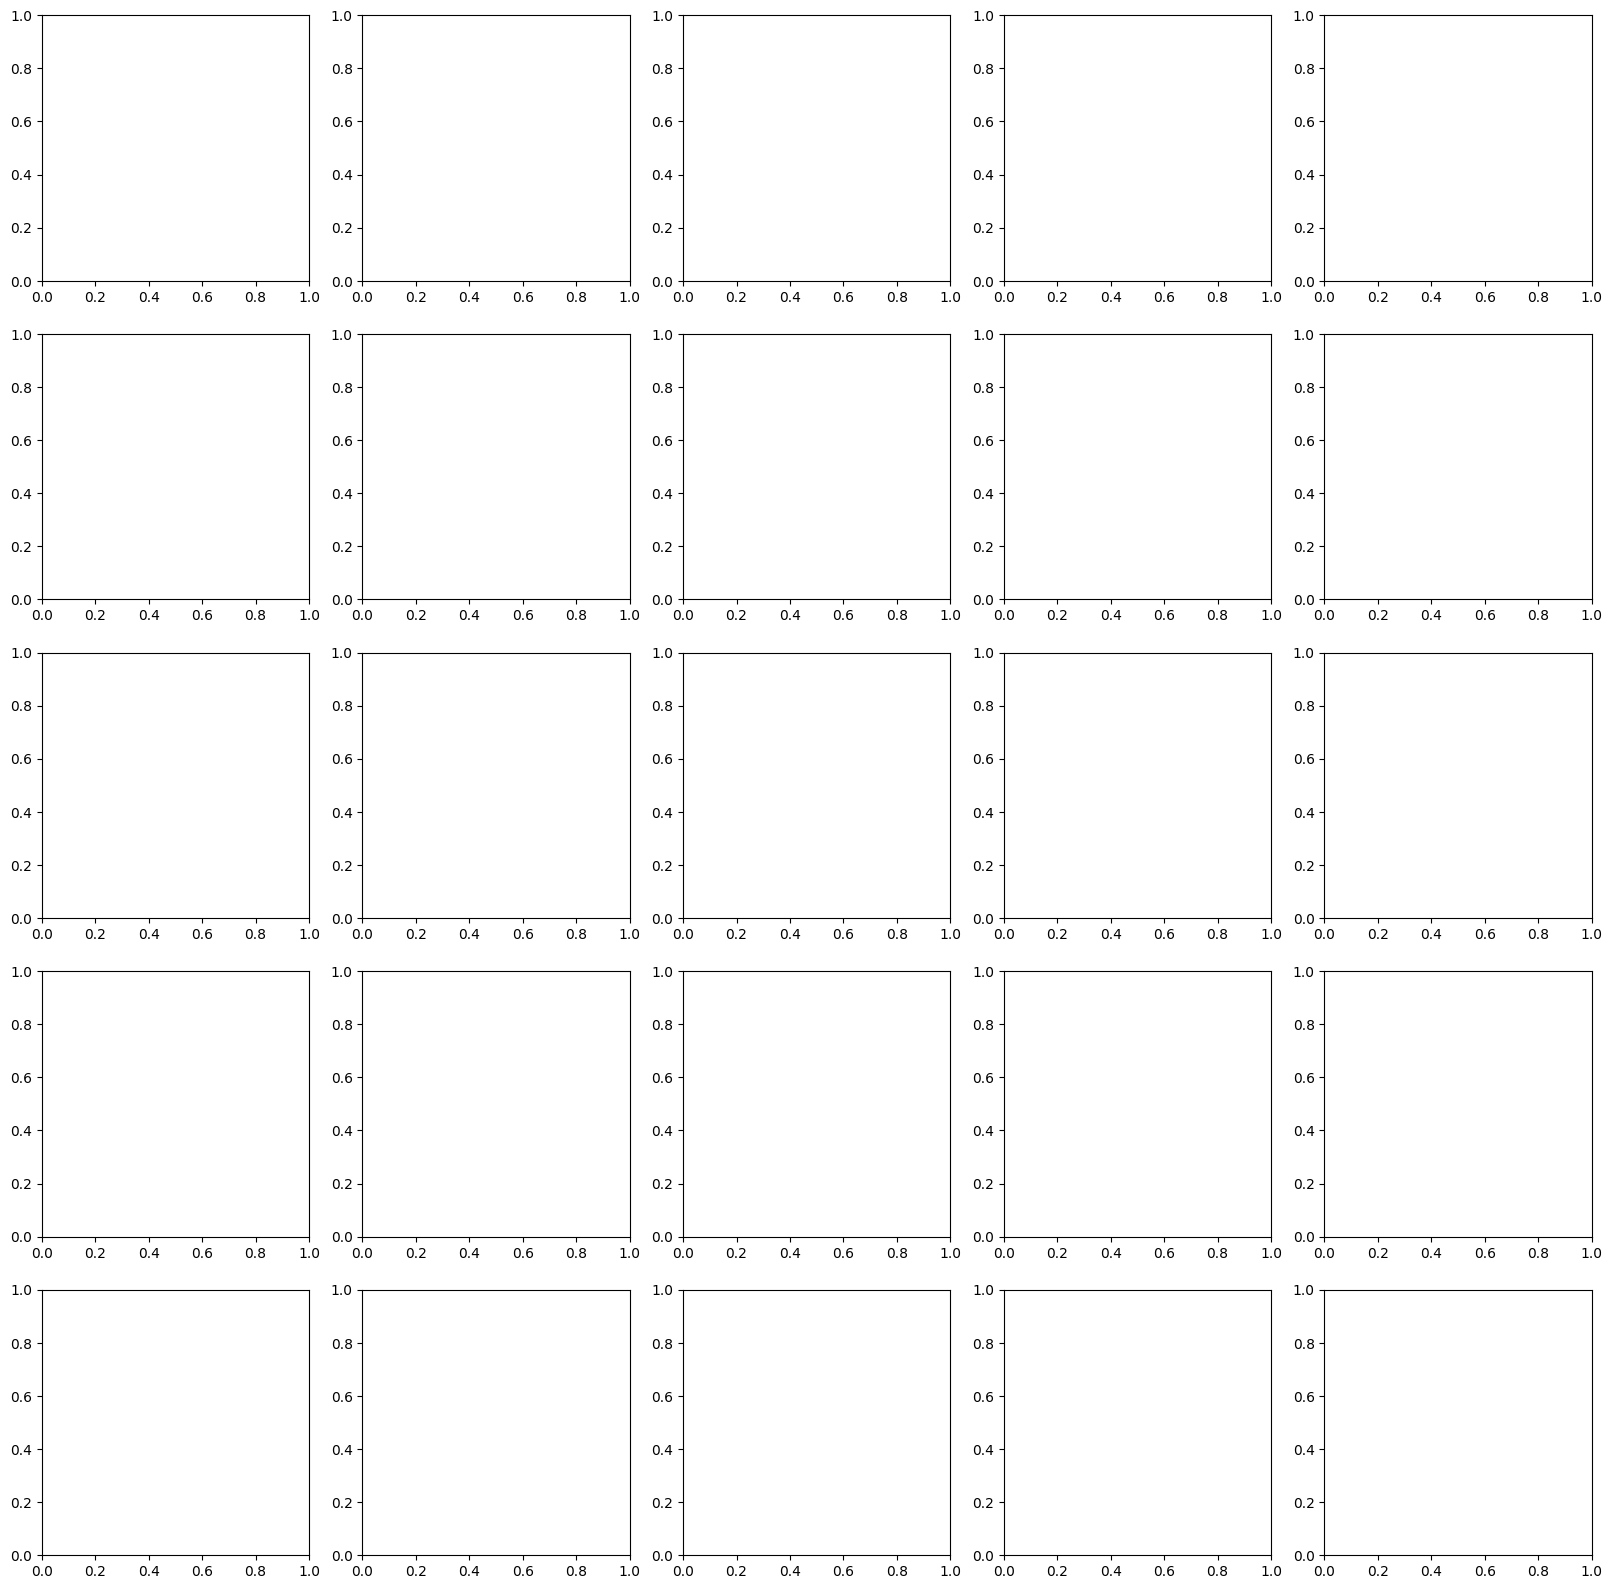

In [12]:
print("\n" + "="*60)
print("Starting training.")
print("="*60)

train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="train",
    output_dir=OUTPUT_DIR,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    checkpoint_every=CHECKPOINT_EVERY,
    visualize_every=VISUALIZE_EVERY,
    image_processor=image_processor,
    device=device
)

## Display some of the output visualizations

The training of the model is already producing some visualizations every N epochs.
Here we open some of the visualizations to look at them from the notebook.

In [ ]:
visualization_dir = os.path.join(OUTPUT_DIR, 'visualizations')
visualization_filenames = sorted(glob(os.path.join(visualization_dir, '*.png')))

In [ ]:
for vis_filename in visualization_filenames:

    img = mpimg.imread(vis_filename)
    
    plt.figure(figsize=(16, 14))
    plt.imshow(img)
    plt.axis("off")
    plt.show()